### **Task 1 - Import Libraries**

In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import tensorflow as tf
import random

import os
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


### **Task 2 - Import TXT -> CSV**

In [ ]:
from google.colab import files
files.upload()
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!pip install kaggle
!kaggle datasets download -d zarif98sjs/gait-in-parkinsons-disease
!unzip gait-in-parkinsons-disease.zip -d gait_data
import os
input_dir = 'gait_data'
print(len(os.listdir(input_dir)))  # Afișează numărul de fișiere din director

Dataset URL: https://www.kaggle.com/datasets/zarif98sjs/gait-in-parkinsons-disease
License(s): unknown
gait-in-parkinsons-disease.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  gait-in-parkinsons-disease.zip
replace gait_data/GaCo01_01.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: 309


In [ ]:
features = ['Time', 'L1' , 'L2', 'L3', 'L4', 'L5', 'L6', 'L7', 'L8', 'R1', 'R2', 'R3', 'R4', 'R5', 'R6', 'R7', 'R8', 'Total_Force_Left', 'Total_Force_Right']
!mkdir CSV
i = 0
for file in os.listdir(input_dir):
    i = i+1
    #print(i)
    if file[0:2]=='Ga' or file[0:2]=='Ju' or file[0:2] == 'Si':
        pass
        #print(file)
        df = pd.read_csv(input_dir + '/' + file, header = None, sep = '\t', on_bad_lines = 'skip')

        df.columns = features

        name = 'CSV/' + file.split('.')[0] + '.csv'
        df.to_csv(name, index = None)

print(i)

309


### **Task 3 - Clasa DATASET**

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import os

# Clasa custom pentru încărcarea datasetului Parkinson
class ParkinsonDataset(Dataset):
    def __init__(self, csv_folder, demographics_df):
        self.csv_folder = csv_folder                      # Calea către folderul cu fișierele CSV (un fișier per pacient)
        self.demographics = demographics_df               # DataFrame cu informațiile demografice (ID, Group etc.)
        self.file_list = os.listdir(csv_folder)           # Lista tuturor fișierelor din folderul CSV

    def __len__(self):
        return len(self.file_list)                        # Returnează câte fișiere/pacienți există

    def __getitem__(self, idx):
        file_name = self.file_list[idx]                   # Numele fișierului pentru pacientul curent
        data = pd.read_csv(os.path.join(self.csv_folder, file_name))  # Citirea fișierului CSV

        subject_id = file_name.split('_')[0]              # Extrage ID-ul pacientului din numele fișierului (ex: 'Ga01_1.csv' -> 'Ga01')

        # Caută în tabelul demografic rândul cu ID-ul respectiv și extrage coloana 'Group'
        group = self.demographics.loc[self.demographics['ID'] == subject_id, 'Group'].values[0]

        # Definirea etichetei: Parkinson = 1, Control = 0
        label = 1 if group == 1 else 0                    # Group=1 -> Parkinson, Group=2 -> Control

        # Convertirea datelor numerice (fără coloana 'Time') într-un tensor PyTorch
        data_tensor = torch.tensor(data.iloc[:, 1:].values, dtype=torch.float32)

        return data_tensor, label                         # Returnează tensorul + eticheta

# Citește fișierul demographics.txt cu separator spațiu
demographics = pd.read_csv(input_dir + '/demographics.txt', sep='\s+')



# Funcție custom de combinare a elementelor într-un batch (cu padding pentru secvențe de lungimi diferite)
def collate_fn(batch):
    data, labels = zip(*batch)                            # Separă datele și etichetele

    lengths = [seq.shape[0] for seq in data]              # Lungimea fiecărei secvențe
    max_len = max(lengths)                                # Lungimea maximă din batch
    num_features = data[0].shape[1]                       # Numărul de coloane (caracteristici)

    padded_data = torch.zeros(len(data), max_len, num_features)  # Creează tensorul de batch cu padding

    for i, seq in enumerate(data):
        padded_data[i, :seq.shape[0], :] = seq            # Completează fiecare secvență în tensor

    labels = torch.tensor(labels, dtype=torch.long)       # Transformă lista de etichete în tensor

    return padded_data, labels, lengths                   # Returnează datele cu padding, etichetele și lungimile originale

# Calea către folderul CSV generat anterior
csv_folder = 'CSV'





from collections import Counter

# Creează datasetul
dataset = ParkinsonDataset(csv_folder, demographics)

# Inițializează un contor pentru etichete
label_counter = Counter()

# Parcurge întregul dataset și contorizează etichetele
for i in range(len(dataset)):
    _, label = dataset[i]
    label_counter[label] += 1

# Afișează rezultatele
print(f"\nPacienți identificați în dataset:")
print(f"Număr pacienți cu Parkinson (label 1): {label_counter[1]}")
print(f"Număr pacienți Control (label 0):      {label_counter[0]}")




# Creează DataLoader-ul pentru a parcurge datele în batch-uri
loader = DataLoader(dataset, batch_size=4, shuffle=True, collate_fn=collate_fn)

# Rulează un singur batch pentru testare
for batch_idx, (data_batch, labels_batch, lengths) in enumerate(loader):
    print(f"Batch {batch_idx}")
    print("Forma datelor (batch, max_len, features):", data_batch.shape)
    print("Labels batch:", labels_batch)
    print("Lungimi originale ale secvențelor:", lengths)
    if batch_idx == 0:
        break

# Statistici demografice de bază
num_total = len(demographics)
num_parkinson = len(demographics[demographics['Group'] == 1])  # Parkinson = 1
num_control = len(demographics[demographics['Group'] == 2])    # Control = 2

print(f"\nNumăr total de pacienți: {num_total}")
print(f"Număr pacienți cu Parkinson: {num_parkinson}")
print(f"Număr pacienți Control: {num_control}")



Pacienți identificați în dataset:
Număr pacienți cu Parkinson (label 1): 214
Număr pacienți Control (label 0):      92
Batch 0
Forma datelor (batch, max_len, features): torch.Size([4, 12119, 18])
Labels batch: tensor([1, 1, 1, 1])
Lungimi originale ale secvențelor: [9184, 9460, 6238, 12119]

Număr total de pacienți: 166
Număr pacienți cu Parkinson: 93
Număr pacienți Control: 73


### **Task 4 - Antrenare**

Device folosit: cuda
Epoch [1/100], Train Loss: 0.6517, Train Acc: 0.6680, Test Loss: 0.6341, Test Acc: 0.6452
✅ Model salvat (cel mai bun până acum)
Epoch [2/100], Train Loss: 0.5875, Train Acc: 0.7131, Test Loss: 0.6647, Test Acc: 0.6452
✅ Model salvat (cel mai bun până acum)
Epoch [3/100], Train Loss: 0.5645, Train Acc: 0.7131, Test Loss: 0.6239, Test Acc: 0.6452
✅ Model salvat (cel mai bun până acum)
Epoch [4/100], Train Loss: 0.5128, Train Acc: 0.7131, Test Loss: 0.6238, Test Acc: 0.6452
✅ Model salvat (cel mai bun până acum)
Epoch [5/100], Train Loss: 0.4728, Train Acc: 0.7418, Test Loss: 0.6140, Test Acc: 0.7258
✅ Model salvat (cel mai bun până acum)
Epoch [6/100], Train Loss: 0.3854, Train Acc: 0.8156, Test Loss: 0.6420, Test Acc: 0.7258
✅ Model salvat (cel mai bun până acum)
Epoch [7/100], Train Loss: 0.3405, Train Acc: 0.8607, Test Loss: 0.5464, Test Acc: 0.7581
✅ Model salvat (cel mai bun până acum)
Epoch [8/100], Train Loss: 0.2879, Train Acc: 0.9057, Test Loss: 0.6238, Tes

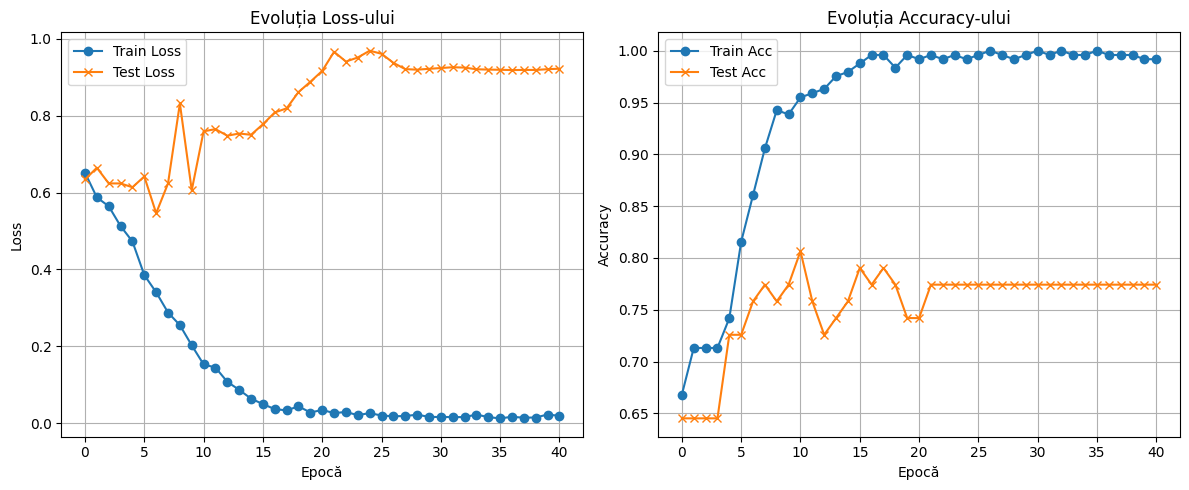

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt

# Verificare GPU disponibil
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device folosit:", device)

# Definirea modelului cu dropout și 2 straturi
class ParkinsonLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes=2, num_layers=2, dropout=0.3):
        super(ParkinsonLSTM, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers=num_layers, dropout=dropout, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.hidden_fc = nn.Linear(hidden_size, 64)
        self.fc = nn.Linear(64, num_classes)

    def forward(self, x, lengths):
        packed = nn.utils.rnn.pack_padded_sequence(x, lengths, batch_first=True, enforce_sorted=False)
        _, (hn, _) = self.lstm(packed)
        out = self.dropout(hn[-1])
        out = torch.relu(self.hidden_fc(out))
        out = self.fc(out)
        return out

# Inițializare parametri model
input_size = 18
hidden_size = 256
num_epochs = 100

# Inițializare model, criterion și optimizer
model = ParkinsonLSTM(input_size, hidden_size, num_classes=2).to(device)
weights = torch.tensor([1.0, 1.0]).to(device)  # Pentru 2 clase: Control și Parkinson
criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

# Împarte datele în train și test (80%-20%)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, collate_fn=collate_fn)

# Early stopping pe baza loss-ului
best_loss = float('inf')
patience = 5
patience_counter = 0

# Liste pentru grafice
train_losses = []
train_accuracies = []
test_losses = []
test_accuracies = []

# Antrenarea modelului
for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []

    for data_batch, labels_batch, lengths in train_loader:
        data_batch = data_batch.to(device)
        labels_batch = labels_batch.to(device)

        optimizer.zero_grad()
        outputs = model(data_batch, lengths)
        loss = criterion(outputs, labels_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        _, predicted = torch.max(outputs.data, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels_batch.cpu().numpy())

    scheduler.step()
    avg_loss = total_loss / len(train_loader)
    acc = accuracy_score(all_labels, all_preds)

    train_losses.append(avg_loss)
    train_accuracies.append(acc)

    # 🔍 Evaluare pe setul de test
    model.eval()
    test_loss = 0
    test_preds = []
    test_labels = []

    with torch.no_grad():
        for test_batch, test_targets, test_lengths in test_loader:
            test_batch = test_batch.to(device)
            test_targets = test_targets.to(device)

            test_outputs = model(test_batch, test_lengths)
            loss = criterion(test_outputs, test_targets)
            test_loss += loss.item()

            _, test_predicted = torch.max(test_outputs.data, 1)
            test_preds.extend(test_predicted.cpu().numpy())
            test_labels.extend(test_targets.cpu().numpy())

    avg_test_loss = test_loss / len(test_loader)
    test_acc = accuracy_score(test_labels, test_preds)

    test_losses.append(avg_test_loss)
    test_accuracies.append(test_acc)

    # ✅ Print complet cu train + test
    print(f'Epoch [{epoch+1}/{num_epochs}], '
          f'Train Loss: {avg_loss:.4f}, Train Acc: {acc:.4f}, '
          f'Test Loss: {avg_test_loss:.4f}, Test Acc: {test_acc:.4f}')

    # Early stopping
    if avg_loss < best_loss:
        best_loss = avg_loss
        patience_counter = 0
        torch.save(model.state_dict(), 'best_model.pth')
        print("✅ Model salvat (cel mai bun până acum)")
    else:
        patience_counter += 1
        print(f"⚠️  Patience: {patience_counter}/{patience}")

    if patience_counter >= patience:
        print("⏹️  Early stopping: loss-ul nu s-a mai îmbunătățit.")
        break

# Grafic pentru evoluția loss-ului și a accuracy-ului
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss', marker='o')
plt.plot(test_losses, label='Test Loss', marker='x')
plt.title('Evoluția Loss-ului')
plt.xlabel('Epocă')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Acc', marker='o')
plt.plot(test_accuracies, label='Test Acc', marker='x')
plt.title('Evoluția Accuracy-ului')
plt.xlabel('Epocă')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


### **Task 5 - Evaluare Model**

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from collections import Counter

def evaluare_model(nume_set, labels, preds):
    label_counts = Counter(labels)
    print(f"\n{'='*30}\nEvaluare pe setul de {nume_set}:")
    print("Distribuția etichetelor reale:")
    print(f"  Control (0):   {label_counts[0]}")
    print(f"  Parkinson (1): {label_counts[1]}")

    class_names = ['Control', 'Parkinson']
    label_ids = [0, 1]

    precision = precision_score(labels, preds, labels=label_ids, average=None, zero_division=0)
    recall = recall_score(labels, preds, labels=label_ids, average=None, zero_division=0)
    f1 = f1_score(labels, preds, labels=label_ids, average=None, zero_division=0)
    accuracy = accuracy_score(labels, preds)

    print(f"\n  Accuracy general: {accuracy:.4f}")

    for i, name in enumerate(class_names):
        print(f"\n  {name}:")
        print(f"    Precision: {precision[i]:.4f}")
        print(f"    Recall:    {recall[i]:.4f}")
        print(f"    F1-Score:  {f1[i]:.4f}")

# Încarcă cel mai bun model și evaluează
model.load_state_dict(torch.load('best_model.pth'))
model.eval()

# 🔍 Evaluare pe setul de train complet
train_preds = []
train_labels = []

with torch.no_grad():
    for data_batch, labels_batch, lengths in train_loader:
        data_batch = data_batch.to(device)
        labels_batch = labels_batch.to(device)

        outputs = model(data_batch, lengths)
        _, predicted = torch.max(outputs.data, 1)

        train_preds.extend(predicted.cpu().numpy())
        train_labels.extend(labels_batch.cpu().numpy())

evaluare_model("train", train_labels, train_preds)

# 🔍 Evaluare pe setul de test complet
test_preds = []
test_labels = []

with torch.no_grad():
    for data_batch, labels_batch, lengths in test_loader:
        data_batch = data_batch.to(device)
        labels_batch = labels_batch.to(device)

        outputs = model(data_batch, lengths)
        _, predicted = torch.max(outputs.data, 1)

        test_preds.extend(predicted.cpu().numpy())
        test_labels.extend(labels_batch.cpu().numpy())

evaluare_model("test", test_labels, test_preds)



Evaluare pe setul de train:
Distribuția etichetelor reale:
  Control (0):   70
  Parkinson (1): 174

  Accuracy general: 0.9959

  Control:
    Precision: 0.9859
    Recall:    1.0000
    F1-Score:  0.9929

  Parkinson:
    Precision: 1.0000
    Recall:    0.9943
    F1-Score:  0.9971

Evaluare pe setul de test:
Distribuția etichetelor reale:
  Control (0):   22
  Parkinson (1): 40

  Accuracy general: 0.7742

  Control:
    Precision: 0.7000
    Recall:    0.6364
    F1-Score:  0.6667

  Parkinson:
    Precision: 0.8095
    Recall:    0.8500
    F1-Score:  0.8293
